# Exemplo detalhado do pipeline do ExperionML

Este notebook foi pensado para **apresentação**. A ideia é mostrar, em um único fluxo, como o ExperionML organiza as principais etapas de um projeto de machine learning supervisionado: limpeza de dados, engenharia de atributos, treinamento de múltiplos modelos e análise final dos resultados.

Ao longo do notebook, cada célula explica **o que está sendo feito**, **por que a etapa existe** e **como ela se encaixa no pipeline completo**. Isso ajuda tanto na demonstração da biblioteca quanto na explicação conceitual do processo para outras pessoas.

## O que será demonstrado

1. Limpeza de dados
   - Tratamento de valores ausentes
   - Codificação de variáveis categóricas
   - Detecção e remoção de outliers
   - Balanceamento do conjunto de treinamento
2. Engenharia de atributos
   - Criação de atributos não lineares
   - Seleção das variáveis mais relevantes
3. Treinamento e validação de múltiplos modelos
   - Ajuste de hiperparâmetros
   - Treinamento no conjunto de treino
   - Avaliação no conjunto de teste
4. Análise dos resultados
   - Cálculo de métricas de desempenho
   - Visualizações para comparar modelos

## Dataset e contexto do problema

Vamos usar a versão reduzida do conjunto de dados de clima australiano, disponível no próprio repositório em `examples/datasets/weatherAUS_small.csv`.

O objetivo é prever a variável **RainTomorrow**, isto é, se vai chover no dia seguinte. Esse é um problema de **classificação binária**, adequado para demonstrar:

- dados numéricos e categóricos no mesmo dataset;
- presença de valores ausentes;
- necessidade de codificação;
- possibilidade de desbalanceamento entre classes;
- comparação entre múltiplos modelos de classificação.

Também escolhemos a versão pequena do dataset porque ela é mais rápida para apresentação e treinamento em notebook, sem perder o valor didático do pipeline.

In [1]:
import pandas as pd
from experionml import ExperionMLClassifier

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

In [2]:
data = pd.read_csv("./datasets/weatherAUS_small.csv")

print(f"Formato do dataset: {data.shape}")
display(data.head())

print("\nDistribuição da variável alvo (proporção):")
display(data["RainTomorrow"].value_counts(normalize=True).rename("proporcao").to_frame())

print("\nColunas com mais valores ausentes:")
display(data.isna().sum().sort_values(ascending=False).head(10).rename("n_ausentes").to_frame())

Formato do dataset: (812, 21)


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,7.7,22.9,0.0,6.0,10.8,0.198381,39.0,0.200000,0.180617,11.0,19.0,61.0,50.0,1024.5,1020.8,5.0,1.0,17.8,21.2,0.0,0
1,-1.0,18.6,0.0,2.8,10.2,0.140449,28.0,0.156250,0.126761,9.0,9.0,55.0,23.0,1021.7,1018.1,1.0,1.0,8.0,17.8,0.0,0
2,11.9,24.1,0.0,1.0,9.9,0.248366,26.0,0.216049,0.154229,15.0,13.0,60.0,49.0,1025.5,1021.3,2.0,1.0,15.8,22.6,0.0,0
3,14.7,26.5,0.0,6.6,10.1,0.198276,57.0,0.177340,0.126761,19.0,30.0,56.0,49.0,1022.5,1018.2,6.0,3.0,21.6,24.9,0.0,0
4,20.5,36.4,0.0,9.8,12.4,0.140449,48.0,0.239295,0.219512,13.0,26.0,39.0,27.0,1006.2,1002.0,7.0,8.0,29.6,35.8,0.0,0



Distribuição da variável alvo (proporção):


,proporcao
RainTomorrow,
0,0.805419
1,0.194581



Colunas com mais valores ausentes:


,n_ausentes
MinTemp,0
MaxTemp,0
Rainfall,0
Evaporation,0
Sunshine,0
WindGustDir,0
WindGustSpeed,0
WindDir9am,0
WindDir3pm,0
WindSpeed9am,0


## Inicializando o ExperionML

Nesta etapa, criamos o objeto principal do experimento. É aqui que o ExperionML identifica a tarefa, separa treino e teste, registra estatísticas do conjunto de dados e passa a orquestrar todo o pipeline.

Para uma apresentação, vale destacar que essa inicialização já entrega contexto importante sobre o problema, como tamanho do dataset, proporção de treino e teste, presença de valores ausentes e quantidade de variáveis categóricas.

In [3]:
experionml = ExperionMLClassifier(
    data,
    y="RainTomorrow",
    random_state=42,
    verbose=2,
)

<< ================== ExperionML ================== >>

Configuração ==================== >>
Tarefa do algoritmo: Binary classification.

Estatísticas do conjunto de dados ==================== >>
Formato: (812, 21)
Tamanho do conjunto de train: 650
Tamanho do conjunto de test: 162
-------------------------------------
Memória: 136.55 kB
Escalonado: False
Valores atípicos: 39 (0.3%)



## 1. Limpeza de dados

A limpeza é a primeira grande etapa do pipeline. Aqui queremos garantir que os dados estejam em um formato utilizável pelos modelos.

### O que vamos fazer

- `clean()`: padroniza o dataset, trata dtypes e codifica a variável alvo quando necessário.
- `impute()`: lida com valores ausentes. Neste exemplo, vamos usar **mediana** para variáveis numéricas e **moda** para categóricas.
- `encode()`: transforma variáveis categóricas em formato numérico.
- `prune()`: detecta e remove outliers do conjunto de treino.
- `balance()`: equilibra as classes no treino usando oversampling, o que é útil quando uma classe aparece menos que a outra.

### Por que a ordem importa

A sequência abaixo não é arbitrária. Primeiro resolvemos inconsistências gerais do dataset, depois tratamos ausentes, em seguida codificamos categorias, removemos valores extremos e só então balanceamos o conjunto de treino. Isso evita aplicar transformações em dados ainda crus e reduz o risco de distorções no processo.

In [4]:
experionml.clean()
experionml.impute(strat_num="median", strat_cat="most_frequent")
experionml.encode(strategy="Target", max_onehot=8, infrequent_to_value=0.03)
experionml.prune(strategy="zscore", method="drop", max_sigma=3)
experionml.balance(strategy="smote")

Ajustando Cleaner...
Limpando os dados...
Ajustando Imputer...
Imputando valores ausentes...
Ajustando Encoder...
Codificando colunas categóricas...
Fitting Pruner...
Removendo valores atípicos...
 --> Removendo 33 valores atípicos.
Oversampling with SMOTE...
 --> Adding 389 samples to class 1.


## 2. Engenharia de atributos

Depois da limpeza, passamos para a etapa de engenharia de atributos. Aqui a lógica é ampliar e refinar a representação do problema para dar mais capacidade aos modelos.

### Etapas aplicadas

- `feature_generation()`: cria combinações não lineares entre atributos existentes. Neste exemplo, usamos a estratégia `dfs`, gerando novas variáveis a partir de operações simples como soma e subtração.
- `feature_selection()`: reduz o número de variáveis, mantendo as mais relevantes para previsão. Isso melhora interpretabilidade e pode reduzir overfitting e custo computacional.

### Observação importante para apresentação

No mundo real, essa etapa pode ser muito mais extensa. Aqui usamos um número reduzido de atributos gerados e um processo compacto de seleção para manter o notebook rápido e claro, mas a mesma estrutura escala para experimentos maiores.

In [5]:
experionml.feature_generation(
    strategy="dfs",
    n_features=20,
    operators=["add", "sub"],
)

experionml.feature_selection(
    strategy="rfecv",
    solver="Tree",
    n_features=12,
)

Ajustando FeatureGenerator...
Gerando novos atributos...
 --> 20 novos atributos foram adicionados.
Ajustando FeatureSelector...
Executando seleção de atributos...
 --> rfecv selecionou 39 atributos do dataset.
   --> Removendo o atributo Sunshine (rank 2).


## 3. Treinamento e validação de múltiplos modelos

Agora que o pipeline de preparação está definido, podemos treinar vários modelos e compará-los sob o mesmo processo. Esse é um dos pontos mais fortes do ExperionML: ele permite testar diferentes algoritmos mantendo o restante do fluxo consistente.

### O que será feito

- Vamos treinar três modelos clássicos: regressão logística, árvore de decisão e random forest.
- Vamos usar a métrica **F1**, adequada quando queremos equilibrar precisão e recall em classificação binária.
- Vamos incluir uma busca curta de hiperparâmetros com `n_trials=3`.

### Por que poucos trials neste notebook

Para apresentação, um número pequeno de trials é suficiente para mostrar o mecanismo de tuning sem deixar o notebook lento demais. Em um experimento real, esse valor pode ser aumentado.

In [6]:
experionml.run(
    models=["LR", "Tree", "RF"],
    metric="f1",
    n_trials=3,
    errors="raise",
)


Training ========================= >>
Models: LR, Tree, RF
Metric: f1


Executando ajuste de hiperparâmetros para LogisticRegression...
| trial | penalty |       C |  solver | max_iter | l1_ratio |      f1 | best_f1 | time_trial | time_ht |    state |
| ----- | ------- | ------- | ------- | -------- | -------- | ------- | ------- | ---------- | ------- | -------- |
| 0     |      l1 |   0.006 | libli.. |      110 |      1.0 |  0.5128 |  0.5128 |     5.695s |  5.695s | COMPLETE |
| 1     |    None |  0.0332 |     sag |      360 |      0.4 |     0.6 |     0.6 |     6.260s | 11.954s | COMPLETE |
| 2     |      l1 |  0.9164 |    saga |      970 |      0.8 |  0.5753 |     0.6 |     5.868s | 17.822s | COMPLETE |
Ajuste de hiperparâmetros ---------------------------
Melhor trial --> 1
Melhores parâmetros:
 --> penalty: None
 --> C: 0.0332
 --> solver: sag
 --> max_iter: 360
 --> l1_ratio: 0.4
Melhor avaliação --> f1: 0.6
Tempo decorrido: 17.822s
Fit ------------------------------------------

## 4. Análise dos resultados

Depois do treinamento, o ExperionML passa a concentrar informações úteis para comparação entre modelos. A análise costuma seguir duas frentes:

- **tabelas de métricas**, para comparação objetiva;
- **visualizações**, para explicar comportamento e desempenho de forma mais intuitiva.

Primeiro, vamos olhar a tabela geral de resultados produzida pelo experimento.

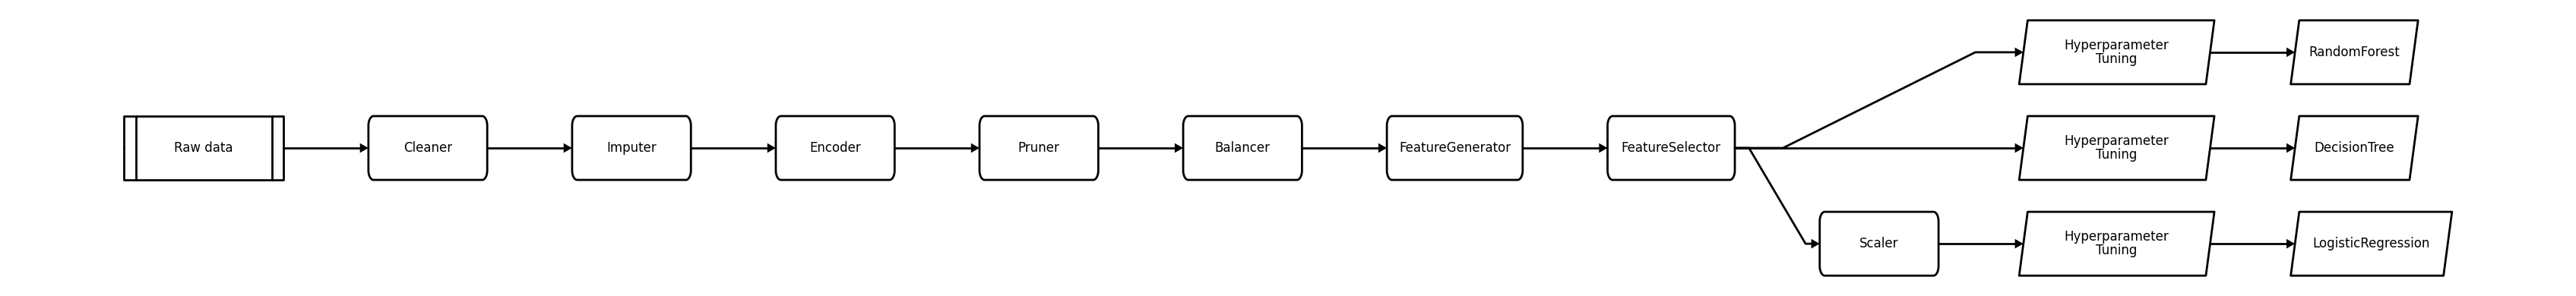

In [7]:
experionml.plot_pipeline()

In [8]:
experionml.results

,f1_ht,time_ht,f1_train,f1_test,time_fit,time
LR,0.600000,17.821713,0.808600,0.617300,0.887938,18.709651
Tree,0.533333,17.350041,0.733300,0.397400,0.067503,17.417544
RF,0.545455,21.218980,0.925500,0.611100,1.605777,22.824757


In [9]:
# Visão complementar com métricas clássicas de classificação
experionml.evaluate(["f1", "precision", "recall", "auc"])

,f1,precision,recall,auc
LR,0.617300,0.510200,0.781200,0.849000
Tree,0.397400,0.252100,0.937500,0.626400
RF,0.611100,0.550000,0.687500,0.838200


In [10]:
print(f"O modelo vencedor foi: {experionml.winner.name}")
print("\nAvaliação detalhada do modelo vencedor no conjunto de teste:")
display(experionml.winner.evaluate(["f1", "precision", "recall", "auc"]).to_frame(name="valor"))

O modelo vencedor foi: LR

Avaliação detalhada do modelo vencedor no conjunto de teste:


,valor
f1,0.6173
precision,0.5102
recall,0.7812
auc,0.8490


## Visualizações para comparação entre modelos

A parte visual é especialmente importante em uma apresentação. Ela permite responder perguntas como:

- qual modelo performou melhor no conjunto de teste;
- como os modelos se comparam em separação entre classes;
- quais atributos mais influenciaram o modelo vencedor.

Abaixo, vamos gerar três visualizações úteis:

1. comparação geral dos modelos;
2. curvas ROC e PRC;
3. importância de atributos do melhor modelo.

In [11]:
experionml.plot_results(title="Comparação geral entre os modelos")

In [12]:
experionml.plot_roc(title="Curva ROC dos modelos")
experionml.plot_prc(title="Curva Precisão-Recall dos modelos")

In [13]:
experionml.winner.plot_feature_importance(
    show=10,
    title="Importância dos atributos no modelo vencedor",
)

In [14]:
!pip install nbformat>=4.2.0

## Conclusão

Este notebook mostra como o ExperionML organiza um fluxo completo de machine learning em poucas etapas de alto nível. Em vez de escrever código disperso para limpeza, transformação, engenharia de atributos, treinamento e análise, o usuário consegue declarar essas etapas de forma estruturada e reproduzível.

### Mensagem principal para apresentar a biblioteca

O valor do ExperionML não está apenas em treinar modelos, mas em **orquestrar o experimento inteiro**. Isso torna mais fácil:

- padronizar pipelines;
- comparar modelos sob as mesmas condições;
- repetir experimentos com consistência;
- explicar o processo de ponta a ponta para times técnicos e não técnicos.

Se quiser transformar este material em uma apresentação ao vivo, uma boa estratégia é executar o notebook por blocos e comentar, em cada etapa, como o ExperionML reduz código repetitivo e centraliza a lógica experimental.